In [1]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from dynamic_routing_analysis import decoding_utils
# import dynamic_routing_analysis as dra
# import npc_lims

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib widget

In [2]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.288.naive.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

In [3]:
all_trials=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.288/consolidated/trials.parquet',storage_options={"skip_signature": "true"}).collect().to_pandas()

In [4]:
all_trials.columns

Index(['start_time', 'stop_time', 'quiescent_start_time',
       'quiescent_stop_time', 'stim_start_time', 'stim_stop_time',
       'response_window_start_time', 'response_window_stop_time',
       'task_control_response_time', 'response_time', 'reward_time',
       'post_response_window_start_time', 'post_response_window_stop_time',
       'stim_name', 'grating_phase', 'block_index', 'rewarded_modality',
       'trial_index', 'trial_index_in_block', 'repeat_index', 'is_response',
       'is_correct', 'is_incorrect', 'is_hit', 'is_false_alarm',
       'is_correct_reject', 'is_miss', 'is_go', 'is_nogo', 'is_rewarded',
       'is_noncontingent_reward', 'is_contingent_reward',
       'is_reward_scheduled', 'is_instruction', 'is_aud_stim', 'is_vis_stim',
       'is_catch', 'is_target', 'is_aud_target', 'is_vis_target',
       'is_nontarget', 'is_aud_nontarget', 'is_vis_nontarget',
       'is_vis_rewarded', 'is_aud_rewarded', 'is_block_switch', 'is_repeat',
       'is_opto', 'is_task_contro

In [26]:
hits_per_block_df={
    'session_id':[],
    'is_engaged':[],
    'hits_per_block_incl_instruction':[],
    'hits_per_block_excl_instruction':[],
    'gte4_blocks_10_hits_incl_instruction':[],
    'gte4_blocks_10_hits_excl_instruction':[],
    'n_blocks_with_10_hits_incl_instruction':[],
    'n_blocks_with_10_hits_excl_instruction':[],
    'vis_target_responses_per_block':[],
    'vis_targets_per_block':[],
    'vis_target_response_fraction_per_block':[],
    'aud_target_responses_per_block':[],
    'aud_targets_per_block':[],
    'aud_target_response_fraction_per_block':[],
}

for sel_session in dr_session_list:
    # sel_session='795555_2025-08-21'
    session_trials=all_trials.query('session_id==@sel_session')
    hits_per_block_incl_instruction=[]
    hits_per_block_excl_instruction=[]
    vis_target_responses_per_block=[]
    vis_targets_per_block=[]
    vis_target_response_fraction_per_block=[]
    aud_target_responses_per_block=[]
    aud_targets_per_block=[]
    aud_target_response_fraction_per_block=[]
    is_engaged=session_table.filter(pl.col('session_id')==sel_session)['is_engaged'].item()

    for block_id in session_trials['block_index'].unique():
        block_trials=session_trials.query('block_index==@block_id')
        hits_per_block_incl_instruction.append(block_trials['is_hit'].sum())
        hits_per_block_excl_instruction.append(block_trials.query('~is_instruction')['is_hit'].sum())

        vis_target_responses_per_block.append(block_trials.query('is_vis_target')['is_response'].sum())
        vis_targets_per_block.append(block_trials['is_vis_target'].sum())
        vis_target_response_fraction_per_block.append(
            vis_target_responses_per_block[-1] / vis_targets_per_block[-1] if vis_targets_per_block[-1] > 0 else np.nan
        )
        aud_target_responses_per_block.append(block_trials.query('is_aud_target')['is_response'].sum())
        aud_targets_per_block.append(block_trials['is_aud_target'].sum())
        aud_target_response_fraction_per_block.append(
            aud_target_responses_per_block[-1] / aud_targets_per_block[-1] if aud_targets_per_block[-1] > 0 else np.nan
        )

    hits_per_block_incl_instruction=np.array(hits_per_block_incl_instruction)
    hits_per_block_excl_instruction=np.array(hits_per_block_excl_instruction)

    hits_per_block_df['session_id'].append(sel_session)
    hits_per_block_df['is_engaged'].append(is_engaged)
    hits_per_block_df['hits_per_block_incl_instruction'].append(hits_per_block_incl_instruction)
    hits_per_block_df['hits_per_block_excl_instruction'].append(hits_per_block_excl_instruction)
    gte4_blocks_10_hits_incl_instruction=(np.sum((hits_per_block_incl_instruction)>=10)>=4)
    gte4_blocks_10_hits_excl_instruction=(np.sum((hits_per_block_excl_instruction)>=10)>=4)
    hits_per_block_df['gte4_blocks_10_hits_incl_instruction'].append(gte4_blocks_10_hits_incl_instruction)
    hits_per_block_df['gte4_blocks_10_hits_excl_instruction'].append(gte4_blocks_10_hits_excl_instruction)
    n_blocks_with_10_hits_incl_instruction=np.sum(hits_per_block_incl_instruction>=10)
    n_blocks_with_10_hits_excl_instruction=np.sum(hits_per_block_excl_instruction>=10)
    hits_per_block_df['n_blocks_with_10_hits_incl_instruction'].append(n_blocks_with_10_hits_incl_instruction)
    hits_per_block_df['n_blocks_with_10_hits_excl_instruction'].append(n_blocks_with_10_hits_excl_instruction)
    hits_per_block_df['vis_target_responses_per_block'].append(vis_target_responses_per_block)
    hits_per_block_df['vis_targets_per_block'].append(vis_targets_per_block)
    hits_per_block_df['aud_target_responses_per_block'].append(aud_target_responses_per_block)
    hits_per_block_df['aud_targets_per_block'].append(aud_targets_per_block)
    hits_per_block_df['vis_target_response_fraction_per_block'].append(vis_target_response_fraction_per_block)
    hits_per_block_df['aud_target_response_fraction_per_block'].append(aud_target_response_fraction_per_block)


hits_per_block_df=pd.DataFrame(hits_per_block_df)
hits_per_block_df

,session_id,is_engaged,hits_per_block_incl_instruction,hits_per_block_excl_instruction,gte4_blocks_10_hits_incl_instruction,gte4_blocks_10_hits_excl_instruction,n_blocks_with_10_hits_incl_instruction,n_blocks_with_10_hits_excl_instruction,vis_target_responses_per_block,vis_targets_per_block,vis_target_response_fraction_per_block,aud_target_responses_per_block,aud_targets_per_block,aud_target_response_fraction_per_block
0,796012_2025-07-10,True,"[24, 22, 22, 19, 20, 19]","[19, 17, 17, 14, 15, 15]",True,True,6,6,"[24, 18, 22, 15, 20, 16]","[24, 18, 23, 15, 20, 17]","[1.0, 1.0, 0.9565217391304348, 1.0, 1.0, 0.941...","[20, 22, 19, 19, 17, 19]","[20, 22, 19, 19, 17, 20]","[1.0, 1.0, 1.0, 1.0, 1.0, 0.95]"
1,796012_2025-07-11,True,"[22, 22, 22, 17, 20, 21]","[17, 17, 17, 13, 15, 16]",True,True,6,6,"[15, 22, 18, 17, 15, 21]","[19, 22, 18, 21, 15, 21]","[0.7894736842105263, 1.0, 1.0, 0.8095238095238...","[22, 16, 22, 16, 20, 17]","[22, 17, 22, 16, 20, 17]","[1.0, 0.9411764705882353, 1.0, 1.0, 1.0, 1.0]"
2,796012_2025-07-14,True,"[26, 20, 23, 20, 22, 20]","[21, 15, 18, 15, 17, 15]",True,True,6,6,"[26, 16, 23, 12, 22, 15]","[26, 16, 23, 12, 22, 15]","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]","[20, 20, 16, 20, 16, 20]","[20, 20, 16, 20, 17, 20]","[1.0, 1.0, 1.0, 1.0, 0.9411764705882353, 1.0]"
3,796012_2025-07-15,True,"[21, 24, 20, 23, 20, 20]","[16, 20, 15, 18, 15, 16]",True,True,6,6,"[16, 24, 18, 23, 15, 20]","[17, 25, 18, 24, 15, 21]","[0.9411764705882353, 0.96, 1.0, 0.958333333333...","[21, 18, 20, 20, 20, 18]","[21, 19, 20, 20, 20, 18]","[1.0, 0.9473684210526315, 1.0, 1.0, 1.0, 1.0]"
4,796847_2025-07-29,False,"[23, 21, 21, 9, 1, 1]","[18, 16, 16, 8, 0, 0]",False,False,3,3,"[23, 17, 21, 6, 1, 1]","[23, 17, 21, 22, 25, 17]","[1.0, 1.0, 1.0, 0.2727272727272727, 0.04, 0.05...","[16, 21, 19, 9, 4, 1]","[17, 21, 19, 26, 20, 23]","[0.9411764705882353, 1.0, 1.0, 0.3461538461538..."
5,796847_2025-07-30,False,"[9, 11, 16, 4, 14, 5]","[4, 8, 16, 1, 9, 1]",False,False,3,1,"[1, 11, 14, 4, 6, 5]","[20, 25, 19, 23, 20, 25]","[0.05, 0.44, 0.7368421052631579, 0.17391304347...","[9, 9, 16, 5, 14, 3]","[22, 21, 24, 19, 22, 20]","[0.4090909090909091, 0.42857142857142855, 0.66..."
6,796847_2025-07-31,True,"[11, 14, 22, 17, 14, 8]","[6, 9, 17, 13, 9, 5]",True,False,5,2,"[11, 6, 22, 11, 14, 1]","[23, 18, 23, 20, 24, 19]","[0.4782608695652174, 0.3333333333333333, 0.956...","[8, 14, 15, 17, 9, 8]","[19, 24, 19, 25, 19, 24]","[0.42105263157894735, 0.5833333333333334, 0.78..."
7,796847_2025-08-01,True,"[22, 11, 20, 11, 15, 14]","[17, 7, 17, 7, 13, 12]",True,True,6,4,"[12, 11, 13, 11, 8, 14]","[19, 24, 16, 27, 21, 24]","[0.631578947368421, 0.4583333333333333, 0.8125...","[22, 11, 20, 12, 15, 10]","[24, 19, 25, 20, 25, 18]","[0.9166666666666666, 0.5789473684210527, 0.8, ..."
8,795555_2025-08-21,False,"[4, 12, 3, 2, 0, 22]","[0, 9, 0, 0, 0, 18]",False,False,2,1,"[4, 3, 3, 0, 0, 5]","[24, 19, 24, 20, 24, 18]","[0.16666666666666666, 0.15789473684210525, 0.1...","[5, 12, 5, 2, 8, 22]","[19, 25, 19, 25, 20, 23]","[0.2631578947368421, 0.48, 0.2631578947368421,..."
9,795555_2025-08-22,False,"[23, 11, 19, 0, 6, 0]","[18, 7, 14, 0, 5, 0]",False,False,3,2,"[1, 11, 3, 0, 0, 0]","[21, 25, 17, 25, 19, 25]","[0.047619047619047616, 0.44, 0.176470588235294...","[23, 14, 19, 4, 6, 2]","[26, 19, 24, 19, 25, 22]","[0.8846153846153846, 0.7368421052631579, 0.791..."


In [6]:
combined_session_table=session_table.join(pl.from_pandas(hits_per_block_df),on='session_id',how='left')
combined_session_table

session_id,is_production,project,date,time,subject_id,subject_age_days,subject_sex,subject_genotype,implant,rig,experimenters,notes,issues,allen_path,cloud_path,task_version,ephys_day,behavior_day,epochs,is_ephys,is_deep_insertions,is_sync,is_video,is_templeton,is_annotated,is_hab,is_task,is_invalid_times,is_naive,is_context_naive,is_late_autorewards,is_spontaneous,is_spontaneous_rewards,is_rf_mapping,is_optotagging,is_optotagging_control,is_opto_perturbation,is_injection_perturbation,is_opto_control,is_injection_control,probe_letters_available,probe_letters_to_skip,probe_letters_annotated,deep_probe_letters_to_skip,areas_perturbed,areas_recorded,task_duration,mean_vis_dprime,mean_aud_dprime,n_passing_blocks,cross_modality_dprime_vis_blocks,cross_modality_dprime_aud_blocks,n_hits,n_contingent_rewards,n_responses,n_trials,is_first_block_aud,is_first_block_vis,is_engaged,is_good_behavior,is_bad_behavior,is_stage_5_passed,is_engaged_right,hits_per_block_incl_instruction,hits_per_block_excl_instruction,gte4_blocks_10_hits_incl_instruction,gte4_blocks_10_hits_excl_instruction,n_blocks_with_10_hits_incl_instruction,n_blocks_with_10_hits_excl_instruction
str,bool,str,str,str,i64,i64,str,str,str,str,list[str],null,list[null],str,str,str,i64,i64,list[str],bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,str,str,str,null,list[str],f64,f64,f64,i64,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],bool,bool,bool,bool,bool,bool,bool,list[i64],list[i64],bool,bool,i32,i32
"""796012_2025-07-10""",true,"""DynamicRouting""","""2025-07-10""","""10:41:58""",796012,123,"""F""","""wt/wt""","""2002""","""NP3""","[""Hannah Cabasco""]",null,[],"""//allen/programs/mindscope/wor…","""s3://aind-open-data/ecephys_79…","""stage 5 ori AMN moving""",1,12,"[""RFMapping"", ""Spontaneous"", … ""Spontaneous""]",true,false,true,true,false,true,false,true,false,false,true,true,true,true,true,false,false,false,false,false,false,"""ABCDEF""","""""","""ABCDEF""","""""",null,"[""ACAd"", ""ACB"", … ""sm""]",3636.41214,1.153371,-1.359192,0,"[0.07687, -0.226256, 0.070454]","[0.085918, 0.104017, 0.080127]","[24.0, 22.0, … 19.0]","[24.0, 22.0, … 19.0]","[64.0, 60.0, … 52.0]","[88.0, 84.0, … 77.0]",false,true,true,false,true,true,true,"[24, 22, … 19]","[19, 17, … 15]",true,true,6,6
"""796012_2025-07-11""",true,"""DynamicRouting""","""2025-07-11""","""13:25:33""",796012,124,"""F""","""wt/wt""","""2002""","""NP3""","[""Hannah Cabasco""]",null,[],"""//allen/programs/mindscope/wor…","""s3://aind-open-data/ecephys_79…","""stage 5 AMN ori moving""",2,13,"[""RFMapping"", ""Spontaneous"", … ""Spontaneous""]",true,false,true,true,false,true,false,true,false,false,true,true,true,true,true,false,false,false,false,false,false,"""ABCDEF""","""""","""ABCDEF""","""""",null,"[""ACAd"", ""ACB"", … ""sm""]",3615.99467,1.508149,-1.325412,1,"[0.435697, -0.986589, 0.091242]","[1.195827, 0.085918, 0.126049]","[22.0, 22.0, … 21.0]","[22.0, 22.0, … 21.0]","[52.0, 55.0, … 57.0]","[85.0, 85.0, … 76.0]",true,false,true,false,true,true,true,"[22, 22, … 21]","[17, 17, … 16]",true,true,6,6
"""796012_2025-07-14""",true,"""DynamicRouting""","""2025-07-14""","""13:30:15""",796012,127,"""F""","""wt/wt""",null,"""NP3""","[""Hannah Cabasco""]",null,[],"""//allen/programs/mindscope/wor…","""s3://aind-open-data/ecephys_79…","""stage 5 ori AMN moving""",3,14,"[""RFMapping"", ""Spontaneous"", … ""Spontaneous""]",true,false,true,true,false,true,false,true,false,false,true,true,true,true,true,false,false,false,false,false,false,"""ABCDEF""","""""","""ABCDEF""","""""",null,"[""ACAd"", ""ACAv"", … ""scwm""]",3639.64887,1.21278,-1.048006,0,"[0.109938, 0.156354, 0.435697]","[0.097232, 0.2283, 0.126049]","[26.0, 20.0, … 20.0]","[26.0, 20.0, … 20.0]","[59.0, 56.0, … 52.0]","[93.0, 74.0, … 71.0]",false,true,true,false,true,true,true,"[26, 20, … 20]","[21, 15, … 15]",true,true,6,6
"""796012_2025-07-15""",true,"""DynamicRouting""","""2025-07-15""","""13:5

In [7]:
session_table.columns

['session_id',
 'is_production',
 'project',
 'date',
 'time',
 'subject_id',
 'subject_age_days',
 'subject_sex',
 'subject_genotype',
 'implant',
 'rig',
 'experimenters',
 'notes',
 'issues',
 'allen_path',
 'cloud_path',
 'task_version',
 'ephys_day',
 'behavior_day',
 'epochs',
 'is_ephys',
 'is_deep_insertions',
 'is_sync',
 'is_video',
 'is_templeton',
 'is_annotated',
 'is_hab',
 'is_task',
 'is_invalid_times',
 'is_naive',
 'is_context_naive',
 'is_late_autorewards',
 'is_spontaneous',
 'is_spontaneous_rewards',
 'is_rf_mapping',
 'is_optotagging',
 'is_optotagging_control',
 'is_opto_perturbation',
 'is_injection_perturbation',
 'is_opto_control',
 'is_injection_control',
 'probe_letters_available',
 'probe_letters_to_skip',
 'probe_letters_annotated',
 'deep_probe_letters_to_skip',
 'areas_perturbed',
 'areas_recorded',
 'task_duration',
 'mean_vis_dprime',
 'mean_aud_dprime',
 'n_passing_blocks',
 'cross_modality_dprime_vis_blocks',
 'cross_modality_dprime_aud_blocks',
 'n_

In [8]:
filtered_session_table=combined_session_table.filter(
    pl.col('is_engaged').eq(True),
    # pl.col('ephys_day').eq(1),
)

filtered_session_table

session_id,is_production,project,date,time,subject_id,subject_age_days,subject_sex,subject_genotype,implant,rig,experimenters,notes,issues,allen_path,cloud_path,task_version,ephys_day,behavior_day,epochs,is_ephys,is_deep_insertions,is_sync,is_video,is_templeton,is_annotated,is_hab,is_task,is_invalid_times,is_naive,is_context_naive,is_late_autorewards,is_spontaneous,is_spontaneous_rewards,is_rf_mapping,is_optotagging,is_optotagging_control,is_opto_perturbation,is_injection_perturbation,is_opto_control,is_injection_control,probe_letters_available,probe_letters_to_skip,probe_letters_annotated,deep_probe_letters_to_skip,areas_perturbed,areas_recorded,task_duration,mean_vis_dprime,mean_aud_dprime,n_passing_blocks,cross_modality_dprime_vis_blocks,cross_modality_dprime_aud_blocks,n_hits,n_contingent_rewards,n_responses,n_trials,is_first_block_aud,is_first_block_vis,is_engaged,is_good_behavior,is_bad_behavior,is_stage_5_passed,is_engaged_right,hits_per_block_incl_instruction,hits_per_block_excl_instruction,gte4_blocks_10_hits_incl_instruction,gte4_blocks_10_hits_excl_instruction,n_blocks_with_10_hits_incl_instruction,n_blocks_with_10_hits_excl_instruction
str,bool,str,str,str,i64,i64,str,str,str,str,list[str],null,list[null],str,str,str,i64,i64,list[str],bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,str,str,str,null,list[str],f64,f64,f64,i64,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],bool,bool,bool,bool,bool,bool,bool,list[i64],list[i64],bool,bool,i32,i32
"""796012_2025-07-10""",true,"""DynamicRouting""","""2025-07-10""","""10:41:58""",796012,123,"""F""","""wt/wt""","""2002""","""NP3""","[""Hannah Cabasco""]",null,[],"""//allen/programs/mindscope/wor…","""s3://aind-open-data/ecephys_79…","""stage 5 ori AMN moving""",1,12,"[""RFMapping"", ""Spontaneous"", … ""Spontaneous""]",true,false,true,true,false,true,false,true,false,false,true,true,true,true,true,false,false,false,false,false,false,"""ABCDEF""","""""","""ABCDEF""","""""",null,"[""ACAd"", ""ACB"", … ""sm""]",3636.41214,1.153371,-1.359192,0,"[0.07687, -0.226256, 0.070454]","[0.085918, 0.104017, 0.080127]","[24.0, 22.0, … 19.0]","[24.0, 22.0, … 19.0]","[64.0, 60.0, … 52.0]","[88.0, 84.0, … 77.0]",false,true,true,false,true,true,true,"[24, 22, … 19]","[19, 17, … 15]",true,true,6,6
"""796012_2025-07-11""",true,"""DynamicRouting""","""2025-07-11""","""13:25:33""",796012,124,"""F""","""wt/wt""","""2002""","""NP3""","[""Hannah Cabasco""]",null,[],"""//allen/programs/mindscope/wor…","""s3://aind-open-data/ecephys_79…","""stage 5 AMN ori moving""",2,13,"[""RFMapping"", ""Spontaneous"", … ""Spontaneous""]",true,false,true,true,false,true,false,true,false,false,true,true,true,true,true,false,false,false,false,false,false,"""ABCDEF""","""""","""ABCDEF""","""""",null,"[""ACAd"", ""ACB"", … ""sm""]",3615.99467,1.508149,-1.325412,1,"[0.435697, -0.986589, 0.091242]","[1.195827, 0.085918, 0.126049]","[22.0, 22.0, … 21.0]","[22.0, 22.0, … 21.0]","[52.0, 55.0, … 57.0]","[85.0, 85.0, … 76.0]",true,false,true,false,true,true,true,"[22, 22, … 21]","[17, 17, … 16]",true,true,6,6
"""796012_2025-07-14""",true,"""DynamicRouting""","""2025-07-14""","""13:30:15""",796012,127,"""F""","""wt/wt""",null,"""NP3""","[""Hannah Cabasco""]",null,[],"""//allen/programs/mindscope/wor…","""s3://aind-open-data/ecephys_79…","""stage 5 ori AMN moving""",3,14,"[""RFMapping"", ""Spontaneous"", … ""Spontaneous""]",true,false,true,true,false,true,false,true,false,false,true,true,true,true,true,false,false,false,false,false,false,"""ABCDEF""","""""","""ABCDEF""","""""",null,"[""ACAd"", ""ACAv"", … ""scwm""]",3639.64887,1.21278,-1.048006,0,"[0.109938, 0.156354, 0.435697]","[0.097232, 0.2283, 0.126049]","[26.0, 20.0, … 20.0]","[26.0, 20.0, … 20.0]","[59.0, 56.0, … 52.0]","[93.0, 74.0, … 71.0]",false,true,true,false,true,true,true,"[26, 20, … 20]","[21, 15, … 15]",true,true,6,6
"""796012_2025-07-15""",true,"""DynamicRouting""","""2025-07-15""","""13:5

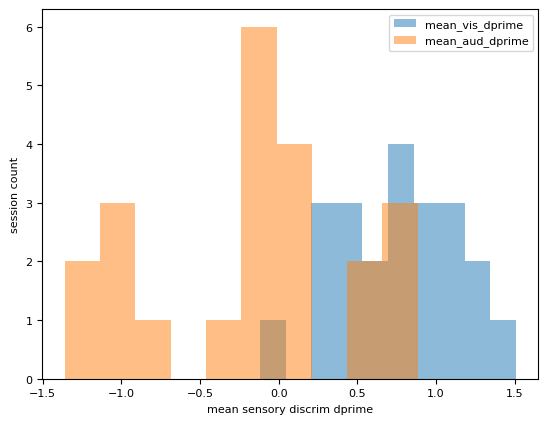

In [9]:
use_session_table=filtered_session_table
xbins=np.arange(-1.5,1.8,0.2)
fig,ax=plt.subplots(1,1)
ax.hist(use_session_table['mean_vis_dprime'],label='mean_vis_dprime',bins=10,alpha=0.5)
ax.hist(use_session_table['mean_aud_dprime'],label='mean_aud_dprime',bins=10,alpha=0.5)
ax.set_xlabel('mean sensory discrim dprime')
ax.set_ylabel('session count')
ax.legend()

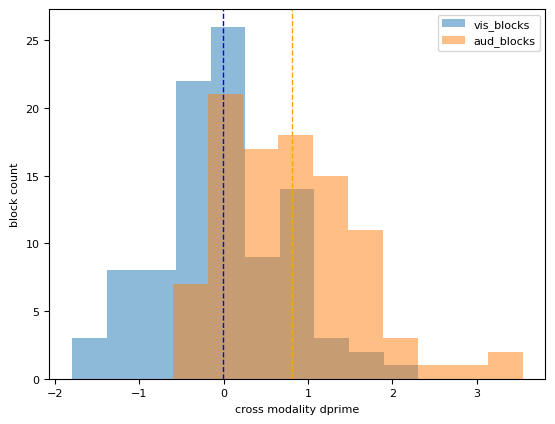

In [10]:
use_session_table=combined_session_table
fig,ax=plt.subplots(1,1)
ax.hist(np.hstack(use_session_table['cross_modality_dprime_vis_blocks'].to_numpy()),label='vis_blocks',alpha=0.5)
ax.axvline(np.mean(np.hstack(use_session_table['cross_modality_dprime_vis_blocks'].to_numpy())), color='blue', linestyle='dashed', linewidth=1)

ax.hist(np.hstack(use_session_table['cross_modality_dprime_aud_blocks'].to_numpy()),label='aud_blocks',alpha=0.5)
ax.axvline(np.mean(np.hstack(use_session_table['cross_modality_dprime_aud_blocks'].to_numpy())), color='orange', linestyle='dashed', linewidth=1)

ax.set_xlabel('cross modality dprime')
ax.set_ylabel('block count')
ax.legend()

Text(0, 0.5, 'block count')

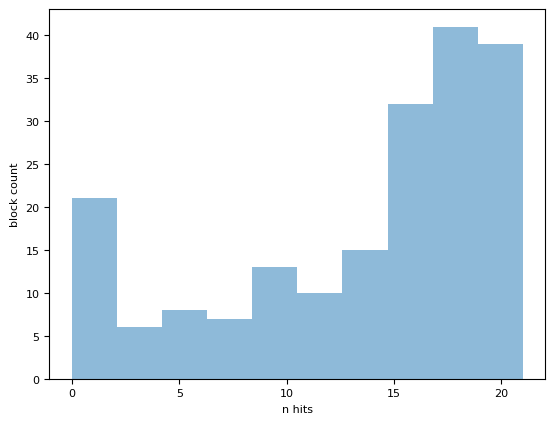

In [11]:
use_session_table=combined_session_table
fig,ax=plt.subplots(1,1)
ax.hist(np.hstack(use_session_table['hits_per_block_excl_instruction'].to_numpy()),label='n_hits',alpha=0.5)
ax.set_xlabel('n hits')
ax.set_ylabel('block count')
# ax.legend()

array([ 0,  1,  2,  4,  3,  3, 19], dtype=int64)

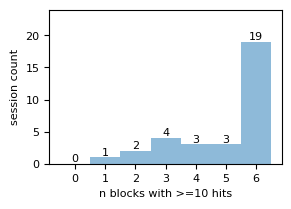

In [12]:
use_session_table=combined_session_table
xbins=np.arange(-0.5,7,1)
fig,ax=plt.subplots(1,1,figsize=(3,2))
# counts,edges=np.histogram(np.sum(np.vstack(use_session_table['hits_per_block_excl_instruction'].to_numpy())>=10,axis=1), bins=xbins)
counts,edges=np.histogram(use_session_table['n_blocks_with_10_hits_incl_instruction'], bins=xbins)
centers=edges[:-1]#(edges[:-1]+edges[1:])/2
ax.bar(centers,counts,width=np.diff(edges),align='edge',alpha=0.5)
for cc,count in enumerate(counts):
    ax.text(edges[cc]+0.5,count,str(count),ha='center',va='bottom')
ax.set_xlabel('n blocks with >=10 hits')
ax.set_ylabel('session count')
ax.set_ylim(0,24)
ax.set_xticks([0,1,2,3,4,5,6])
counts

In [13]:
# edges[np.where(counts==count)[0]]+1
edges
# counts

array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5])

In [14]:
use_session_table[['session_id','n_hits']]

session_id,n_hits
str,list[f64]
"""796012_2025-07-10""","[24.0, 22.0, … 19.0]"
"""796012_2025-07-11""","[22.0, 22.0, … 21.0]"
"""796012_2025-07-14""","[26.0, 20.0, … 20.0]"
"""796012_2025-07-15""","[21.0, 24.0, … 20.0]"
"""796847_2025-07-29""","[23.0, 21.0, … 1.0]"
…,…
"""814666_2025-11-11""","[24.0, 24.0, … 11.0]"
"""831994_2025-12-15""","[20.0, 20.0, … 23.0]"
"""831994_2025-12-16""","[21.0, 22.0, … 19.0]"


Text(0, 0.5, 'cross modality dprime')

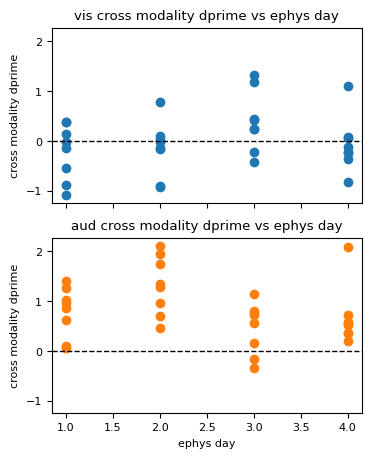

In [15]:
#cross modal dprime vs ephys day

use_session_table=session_table

ephys_day=use_session_table['ephys_day'].to_numpy()
cross_modal_dprime_vis=np.mean(np.vstack(use_session_table['cross_modality_dprime_vis_blocks'].to_numpy()),axis=1)
cross_modal_dprime_aud=np.mean(np.vstack(use_session_table['cross_modality_dprime_aud_blocks'].to_numpy()),axis=1)

fig,ax=plt.subplots(2,1,sharex=True,sharey=True,figsize=(4,5))

ax[0].axhline(0,color='black',linestyle='dashed',linewidth=1)
ax[0].scatter(ephys_day,cross_modal_dprime_vis,label='vis blocks')
ax[0].set_title('vis cross modality dprime vs ephys day')

ax[1].axhline(0,color='black',linestyle='dashed',linewidth=1)
ax[1].scatter(ephys_day,cross_modal_dprime_aud,label='aud blocks',color='tab:orange')
ax[1].set_title('aud cross modality dprime vs ephys day')

ax[1].set_xlabel('ephys day')
ax[0].set_ylabel('cross modality dprime')
ax[1].set_ylabel('cross modality dprime')

In [16]:
use_session_table=session_table

use_session_table.with_columns(
    pl.col('cross_modality_dprime_vis_blocks').list.mean().alias('mean_cross_modality_dprime_vis'),
    pl.col('cross_modality_dprime_aud_blocks').list.mean().alias('mean_cross_modality_dprime_aud')
).group_by('subject_id').agg([
    pl.col('ephys_day'),
    pl.col('mean_cross_modality_dprime_vis'),
    pl.col('mean_cross_modality_dprime_aud'),
])

subject_id,ephys_day,mean_cross_modality_dprime_vis,mean_cross_modality_dprime_aud
i64,list[i64],list[f64],list[f64]
796012,"[1, 2, … 4]","[-0.026311, -0.153216, … -0.114528]","[0.090021, 0.469265, … 0.195844]"
810752,"[1, 2, … 4]","[-1.081766, -0.907704, … -0.355752]","[1.023026, 2.115397, … 0.369794]"
795555,"[1, 2, … 4]","[-0.877993, -0.917444, … -0.825565]","[1.269673, 1.946506, … 0.732156]"
796847,"[1, 2, … 4]","[-0.137295, -0.027106, … -0.240228]","[0.051051, 0.695071, … 0.519253]"
807082,"[1, 2, … 4]","[0.375067, 0.100532, … 1.09564]","[0.964176, 1.753648, … 2.088202]"
798632,"[1, 2, … 4]","[0.388073, 0.04499, … -0.22237]","[0.868341, 1.348914, … 0.579906]"
831994,"[1, 2, … 4]","[0.14007, -0.143108, … 0.084153]","[0.623156, 0.965211, … 0.568219]"
814666,"[1, 2, … 4]","[-0.550627, 0.781907, … 0.055401]","[1.396665, 1.282281, … 0.366528]"


Text(0, 0.5, 'cross modality dprime')

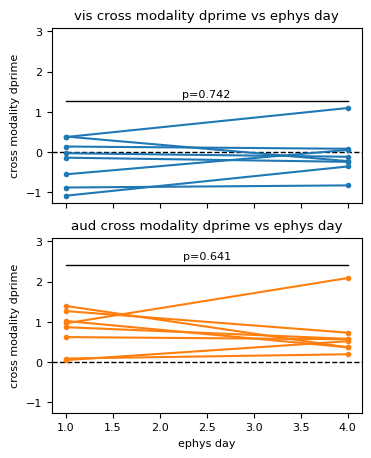

In [17]:
#cross modal dprime vs ephys day

use_session_table=combined_session_table

dprime_by_session=use_session_table.with_columns(
    pl.col('cross_modality_dprime_vis_blocks').list.mean().alias('mean_cross_modality_dprime_vis'),
    pl.col('cross_modality_dprime_aud_blocks').list.mean().alias('mean_cross_modality_dprime_aud')
).group_by('subject_id').agg([
    pl.col('ephys_day'),
    pl.col('mean_cross_modality_dprime_vis'),
    pl.col('mean_cross_modality_dprime_aud'),
])

fig,ax=plt.subplots(2,1,sharex=True,sharey=True,figsize=(4,5))

day1=np.vstack(dprime_by_session['mean_cross_modality_dprime_vis'].to_numpy())[:,0]
day4=np.vstack(dprime_by_session['mean_cross_modality_dprime_vis'].to_numpy())[:,3]
s,p=stats.wilcoxon(day1,day4)

ax[0].axhline(0,color='black',linestyle='dashed',linewidth=1)
ax[0].plot(np.vstack(dprime_by_session['ephys_day'].to_numpy())[:,[0,3]].T, np.vstack(dprime_by_session['mean_cross_modality_dprime_vis'].to_numpy())[:,[0,3]].T, label='vis blocks',color='tab:blue',marker='.')
ax[0].plot([1,4],[np.max(np.hstack([day1,day4]))*1.15,np.max(np.hstack([day1,day4]))*1.15],color='black',linewidth=1)
ax[0].text(2.5,np.max(np.hstack([day1,day4]))*1.2,f'p={p:.3f}',ha='center',va='bottom')
ax[0].set_title('vis cross modality dprime vs ephys day')
ax[0].set_ylabel('cross modality dprime')

day1=np.vstack(dprime_by_session['mean_cross_modality_dprime_aud'].to_numpy())[:,0]
day4=np.vstack(dprime_by_session['mean_cross_modality_dprime_aud'].to_numpy())[:,3]
s,p=stats.wilcoxon(day1,day4)

ax[1].axhline(0,color='black',linestyle='dashed',linewidth=1)
ax[1].plot(np.vstack(dprime_by_session['ephys_day'].to_numpy())[:,[0,3]].T, np.vstack(dprime_by_session['mean_cross_modality_dprime_aud'].to_numpy())[:,[0,3]].T, label='aud blocks',color='tab:orange',marker='.')
ax[1].set_title('aud cross modality dprime vs ephys day')
ax[1].plot([1,4],[np.max(np.hstack([day1,day4]))*1.15,np.max(np.hstack([day1,day4]))*1.15],color='black',linewidth=1)
ax[1].text(2.5,np.max(np.hstack([day1,day4]))*1.2,f'p={p:.3f}',ha='center',va='bottom')

ylims=ax[1].get_ylim()
ax[1].set_ylim(ylims[0],ylims[1]*1.2)
ax[1].set_xlabel('ephys day')
ax[1].set_ylabel('cross modality dprime')

In [18]:
day1=np.vstack(dprime_by_session['mean_cross_modality_dprime_vis'].to_numpy())[:,0]
day4=np.vstack(dprime_by_session['mean_cross_modality_dprime_vis'].to_numpy())[:,3]
s,p=stats.wilcoxon(day1,day4)

In [19]:
day1=np.vstack(dprime_by_session['mean_cross_modality_dprime_aud'].to_numpy())[:,0]
day4=np.vstack(dprime_by_session['mean_cross_modality_dprime_aud'].to_numpy())[:,3]
s,p=stats.wilcoxon(day1,day4)

In [20]:
np.vstack(dprime_by_session['mean_cross_modality_dprime_aud'].to_numpy())[:,[0,3]]

array([[0.62315577, 0.56821854],
       [0.05105122, 0.51925274],
       [0.09002059, 0.19584448],
       [1.26967264, 0.73215627],
       [0.9641764 , 2.08820175],
       [0.86834055, 0.57990597],
       [1.02302632, 0.36979435],
       [1.39666482, 0.36652827]])

(-0.5, 2.0)

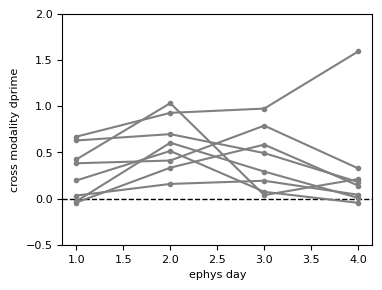

In [21]:
use_session_table=session_table

dprime_by_session=use_session_table.with_columns(
    pl.col('cross_modality_dprime_vis_blocks').list.mean().alias('mean_cross_modality_dprime_vis'),
    pl.col('cross_modality_dprime_aud_blocks').list.mean().alias('mean_cross_modality_dprime_aud')
).group_by('subject_id').agg([
    pl.col('ephys_day'),
    pl.col('mean_cross_modality_dprime_vis'),
    pl.col('mean_cross_modality_dprime_aud'),
])

fig,ax=plt.subplots(1,1,sharex=True,sharey=True,figsize=(4,3))

ax.axhline(0,color='black',linestyle='dashed',linewidth=1)
ax.plot(
    np.vstack(dprime_by_session['ephys_day'].to_numpy()).T, 
    ((np.vstack(dprime_by_session['mean_cross_modality_dprime_vis'].to_numpy())+
    np.vstack(dprime_by_session['mean_cross_modality_dprime_aud'].to_numpy()))/2).T, 
    label='vis & aud average',color='grey',marker='.')
ax.set_ylabel('cross modality dprime')
ax.set_xlabel('ephys day')
ax.set_ylim(-0.5,2)


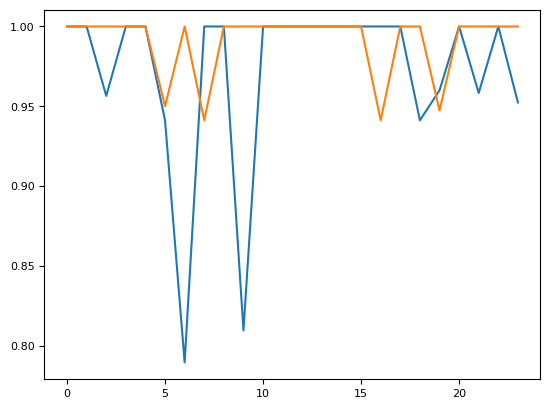

In [30]:
fig,ax=plt.subplots(1,1)
ax.plot(np.hstack(hits_per_block_df.iloc[0:4]['vis_target_response_fraction_per_block']))
ax.plot(np.hstack(hits_per_block_df.iloc[0:4]['aud_target_response_fraction_per_block']))